# Boston Housing Data Analysis: NOx vs Distance to Employment Centers

This notebook analyzes the relationship between:
- `dis`: weighted mean of distances to five Boston employment centers
- `nox`: nitrogen oxides concentration (parts per 10 million)

We'll explore this relationship using:
1. Polynomial regression with varying degrees
2. Regression splines with different degrees of freedom

Both approaches will use cross-validation for model selection.

In [17]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import SplineTransformer
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib for better plotting
plt.style.use('seaborn')
%matplotlib inline

OSError: 'seaborn' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

## Load and Prepare Data

First, we'll load the Boston dataset and extract the variables we need: `dis` and `nox`.

Dataset shape: (506, 13)

Summary statistics:
              dis         nox
count  506.000000  506.000000
mean     3.795043    0.554695
std      2.105710    0.115878
min      1.129600    0.385000
25%      2.100175    0.449000
50%      3.207450    0.538000
75%      5.188425    0.624000
max     12.126500    0.871000


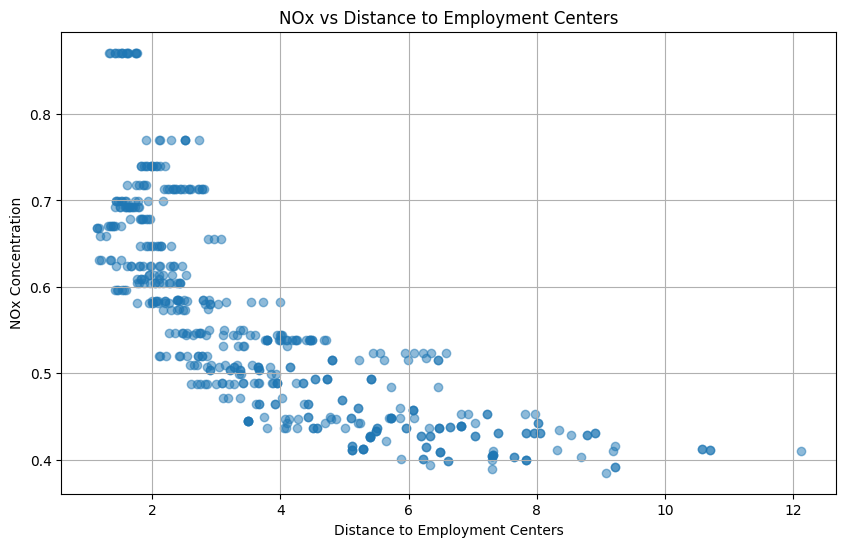

In [ ]:
# Load Boston data from CSV
boston = pd.read_csv('Boston.csv')

# Extract predictor (dis) and response (nox)
X = boston['dis'].values.reshape(-1, 1)
y = boston['nox'].values

# Print summary statistics
print("Dataset shape:", boston.shape)
print("\nSummary statistics:")
print(boston[['dis', 'nox']].describe())

# Create scatter plot of the data
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5)
plt.xlabel('Distance to Employment Centers')
plt.ylabel('NOx Concentration')
plt.title('NOx vs Distance to Employment Centers')
plt.grid(True)
plt.show()

## Cubic Polynomial Regression

We'll use the `poly()` function from ISLP.models to fit a cubic polynomial regression to predict NOx concentrations from distance.

Cubic Polynomial Regression Results:
R-squared: 0.7148
Residual Sum of Squares: 1.9341

Feature names: ['dis' 'dis^2' 'dis^3']

Coefficients:
dis: -0.1821
dis^2: 0.0219
dis^3: -0.0009
Intercept: 0.9341


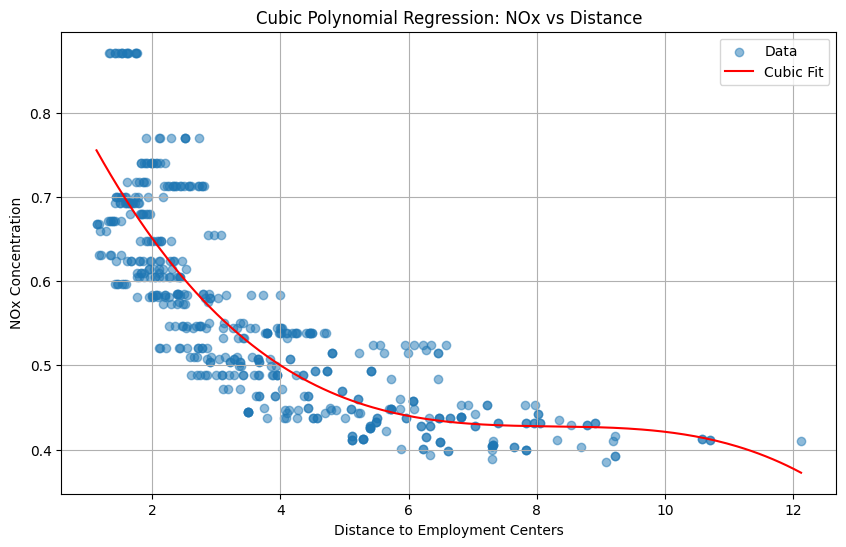

In [ ]:
# Fit cubic polynomial regression
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)

# Generate points for smooth curve
X_new = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_new_poly = poly_features.transform(X_new)
y_pred = model.predict(X_new_poly)

# Calculate R-squared and RSS
r2 = model.score(X_poly, y)
rss = np.sum((y - model.predict(X_poly))**2)

# Print model summary
print("Cubic Polynomial Regression Results:")
print(f"R-squared: {r2:.4f}")
print(f"Residual Sum of Squares: {rss:.4f}")
print("\nFeature names:", poly_features.get_feature_names_out(['dis']))
print("\nCoefficients:")
for name, coef in zip(poly_features.get_feature_names_out(['dis']), model.coef_):
    print(f"{name}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Data')
plt.plot(X_new, y_pred, 'r-', label='Cubic Fit')
plt.xlabel('Distance to Employment Centers')
plt.ylabel('NOx Concentration')
plt.title('Cubic Polynomial Regression: NOx vs Distance')
plt.legend()
plt.grid(True)
plt.show()

## Multiple Polynomial Degrees Analysis

We'll fit polynomials of degrees 1 through 10 and compare their performance using RSS.

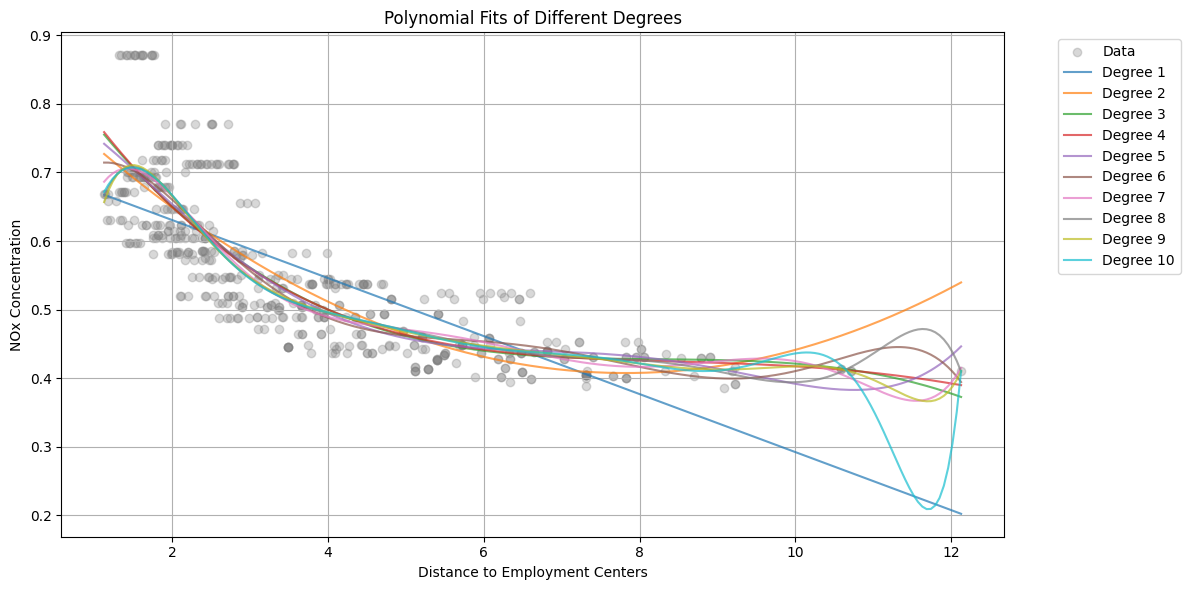

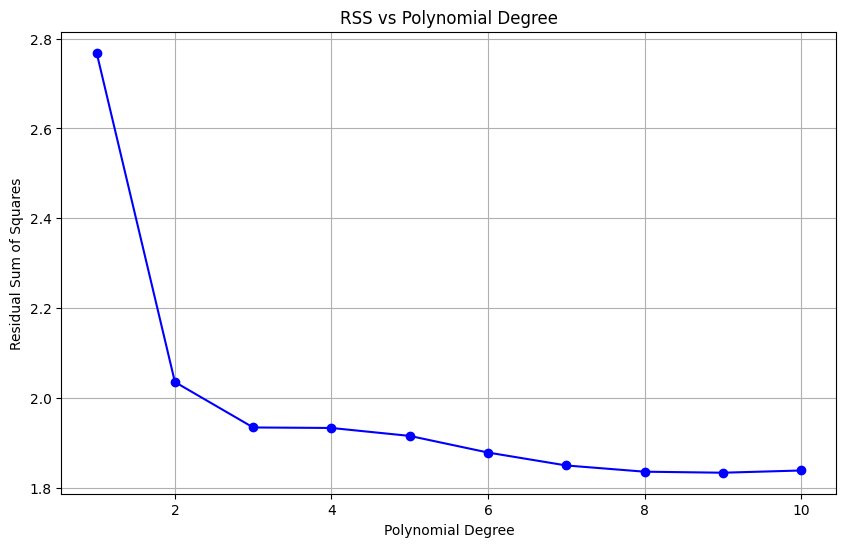


Residual Sum of Squares for each polynomial degree:
Degree 1: 2.7686
Degree 2: 2.0353
Degree 3: 1.9341
Degree 4: 1.9330
Degree 5: 1.9153
Degree 6: 1.8783
Degree 7: 1.8495
Degree 8: 1.8356
Degree 9: 1.8333
Degree 10: 1.8383


In [18]:
# Fit polynomials of different degrees
degrees = range(1, 11)
rss_values = []
models = []

plt.figure(figsize=(12, 6))
plt.scatter(X, y, alpha=0.3, label='Data', color='gray')

for degree in degrees:
    # Create polynomial features
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly_features.fit_transform(X)
    
    # Fit model
    model = LinearRegression()
    model.fit(X_poly, y)
    
    # Calculate RSS
    y_pred = model.predict(X_poly)
    rss = np.sum((y - y_pred)**2)
    rss_values.append(rss)
    models.append(model)
    
    # Generate smooth curve for plotting
    X_new = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    X_new_poly = poly_features.transform(X_new)
    y_new = model.predict(X_new_poly)
    
    plt.plot(X_new, y_new, label=f'Degree {degree}', alpha=0.7)

plt.xlabel('Distance to Employment Centers')
plt.ylabel('NOx Concentration')
plt.title('Polynomial Fits of Different Degrees')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot RSS values
plt.figure(figsize=(10, 6))
plt.plot(degrees, rss_values, 'bo-')
plt.xlabel('Polynomial Degree')
plt.ylabel('Residual Sum of Squares')
plt.title('RSS vs Polynomial Degree')
plt.grid(True)
plt.show()

# Print RSS values
print("\nResidual Sum of Squares for each polynomial degree:")
for degree, rss in zip(degrees, rss_values):
    print(f"Degree {degree}: {rss:.4f}")

## Cross-Validation for Optimal Polynomial Degree

We'll use k-fold cross-validation to select the optimal degree for the polynomial regression.

Optimal polynomial degree from cross-validation: 9


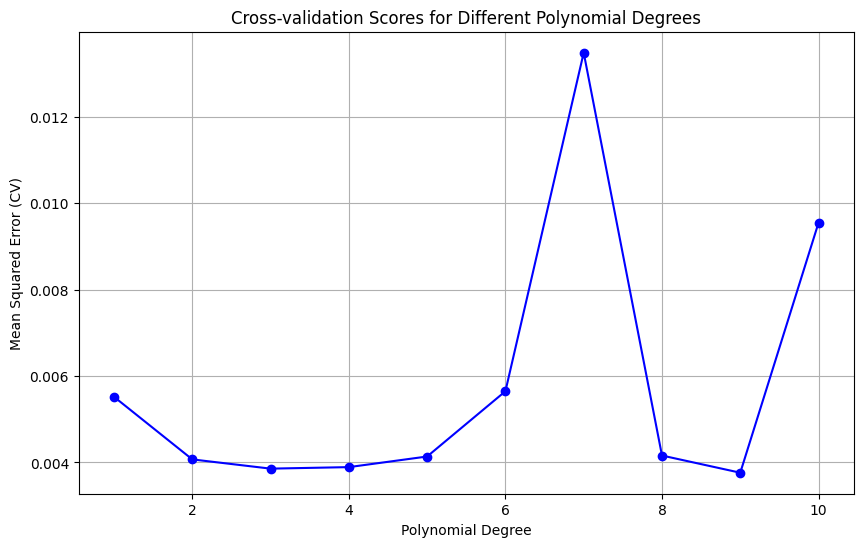

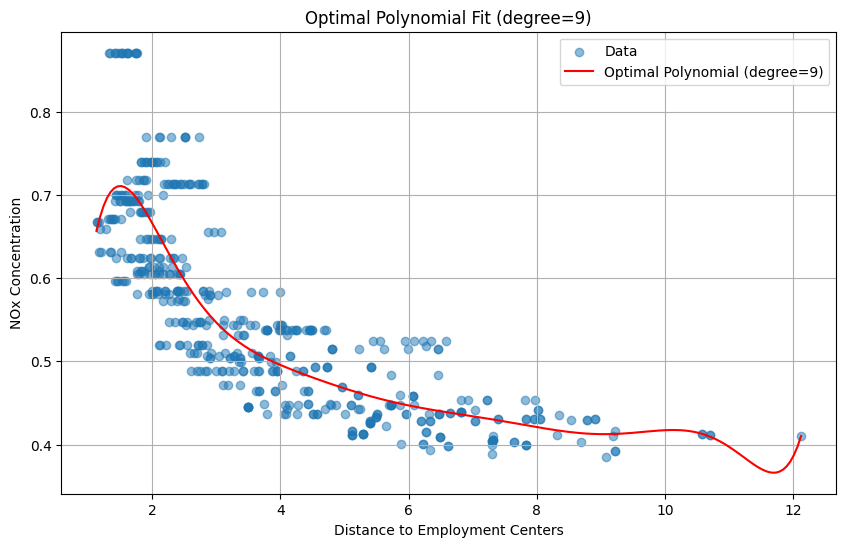


Optimal model coefficients:
dis: 5.1775
dis^2: -4.4603
dis^3: 2.0308
dis^4: -0.5572
dis^5: 0.0968
dis^6: -0.0107
dis^7: 0.0007
dis^8: -0.0000
dis^9: 0.0000
Intercept: -1.6777


In [19]:
# Perform k-fold cross-validation for different polynomial degrees
n_folds = 5
degrees = range(1, 11)
cv_scores = []

for degree in degrees:
    # Create polynomial features
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly_features.fit_transform(X)
    
    # Perform cross-validation
    model = LinearRegression()
    scores = -cross_val_score(model, X_poly, y, 
                           cv=KFold(n_splits=n_folds, shuffle=True, random_state=42),
                           scoring='neg_mean_squared_error')
    cv_scores.append(np.mean(scores))

# Find optimal degree
optimal_degree = degrees[np.argmin(cv_scores)]
print(f"Optimal polynomial degree from cross-validation: {optimal_degree}")

# Plot cross-validation scores
plt.figure(figsize=(10, 6))
plt.plot(degrees, cv_scores, 'bo-')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (CV)')
plt.title('Cross-validation Scores for Different Polynomial Degrees')
plt.grid(True)
plt.show()

# Fit model with optimal degree
poly_features = PolynomialFeatures(degree=optimal_degree, include_bias=False)
X_poly_optimal = poly_features.fit_transform(X)
model_optimal = LinearRegression()
model_optimal.fit(X_poly_optimal, y)

# Generate predictions for plotting
X_new = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_new_poly = poly_features.transform(X_new)
y_pred = model_optimal.predict(X_new_poly)

# Plot the optimal fit
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Data')
plt.plot(X_new, y_pred, 'r-', label=f'Optimal Polynomial (degree={optimal_degree})')
plt.xlabel('Distance to Employment Centers')
plt.ylabel('NOx Concentration')
plt.title(f'Optimal Polynomial Fit (degree={optimal_degree})')
plt.legend()
plt.grid(True)
plt.show()

# Print coefficients
print("\nOptimal model coefficients:")
feature_names = poly_features.get_feature_names_out(['dis'])
for name, coef in zip(feature_names, model_optimal.coef_):
    print(f"{name}: {coef:.4f}")
print(f"Intercept: {model_optimal.intercept_:.4f}")

## Regression Spline with Fixed Degrees of Freedom

We'll use the `bs()` function to fit a regression spline with 4 degrees of freedom. The knots will be placed at quartiles of the predictor variable.

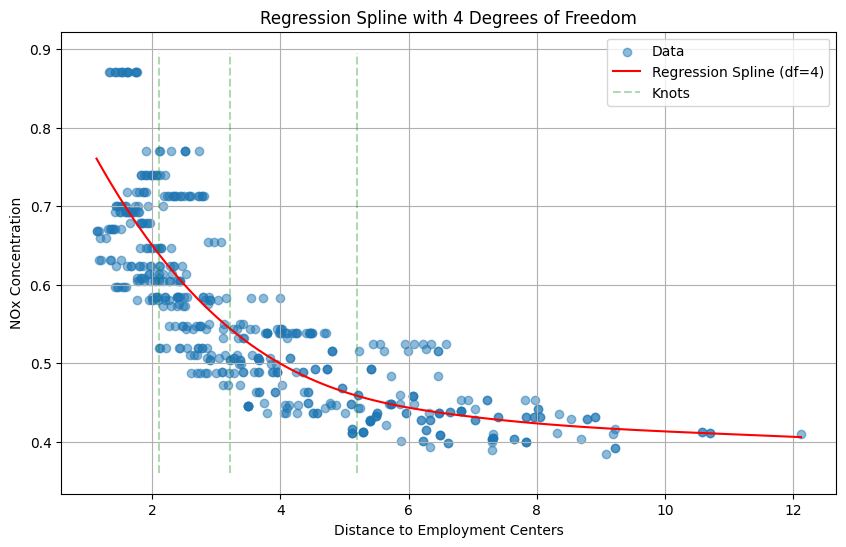

RSS for regression spline (df=4): 1.9299

Knot locations:
Knot 1: 2.10
Knot 2: 3.21
Knot 3: 5.19


In [20]:
# Create spline transformer with 4 degrees of freedom
n_knots = 3  # Will result in 4 degrees of freedom
knots = np.percentile(X.ravel(), np.linspace(0, 100, n_knots + 2)[1:-1])
spline = SplineTransformer(n_knots=n_knots, degree=3, include_bias=False)

# Fit spline transformation
X_spline = spline.fit_transform(X)
model_spline = LinearRegression()
model_spline.fit(X_spline, y)

# Calculate RSS
y_pred_spline = model_spline.predict(X_spline)
rss_spline = np.sum((y - y_pred_spline)**2)

# Generate predictions for smooth curve
X_new = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_new_spline = spline.transform(X_new)
y_new_spline = model_spline.predict(X_new_spline)

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Data')
plt.plot(X_new, y_new_spline, 'r-', label='Regression Spline (df=4)')
plt.vlines(knots, plt.ylim()[0], plt.ylim()[1], 'g', linestyles='dashed', alpha=0.3, label='Knots')
plt.xlabel('Distance to Employment Centers')
plt.ylabel('NOx Concentration')
plt.title('Regression Spline with 4 Degrees of Freedom')
plt.legend()
plt.grid(True)
plt.show()

print(f"RSS for regression spline (df=4): {rss_spline:.4f}")
print("\nKnot locations:")
for i, knot in enumerate(knots, 1):
    print(f"Knot {i}: {knot:.2f}")

## Multiple Spline Degrees of Freedom Analysis

We'll fit regression splines with different degrees of freedom and compare their performance.

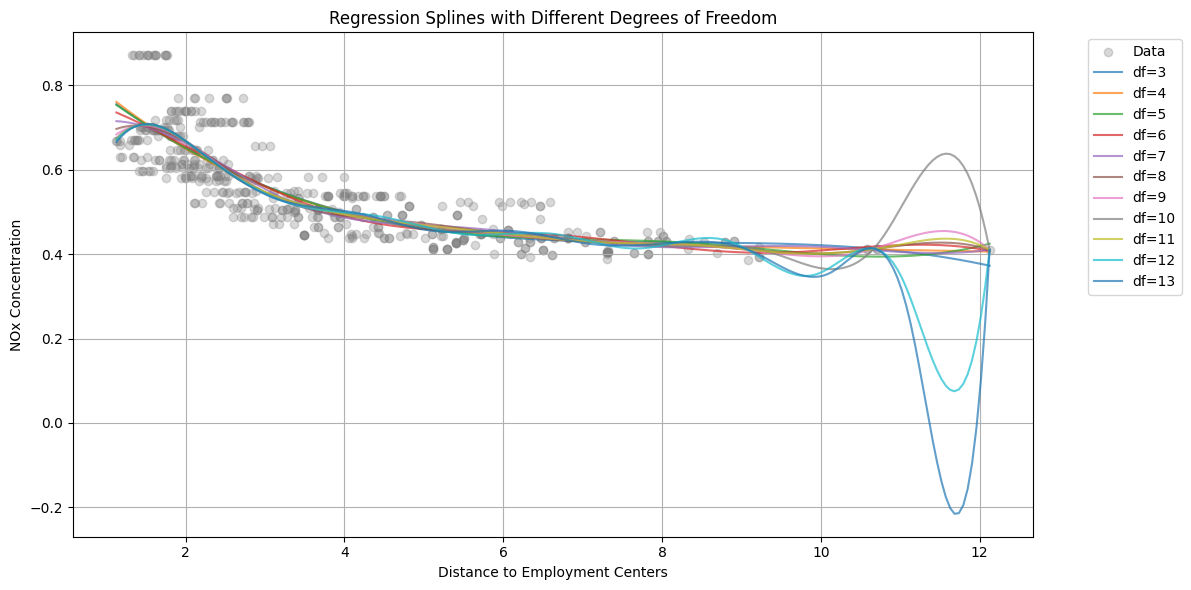

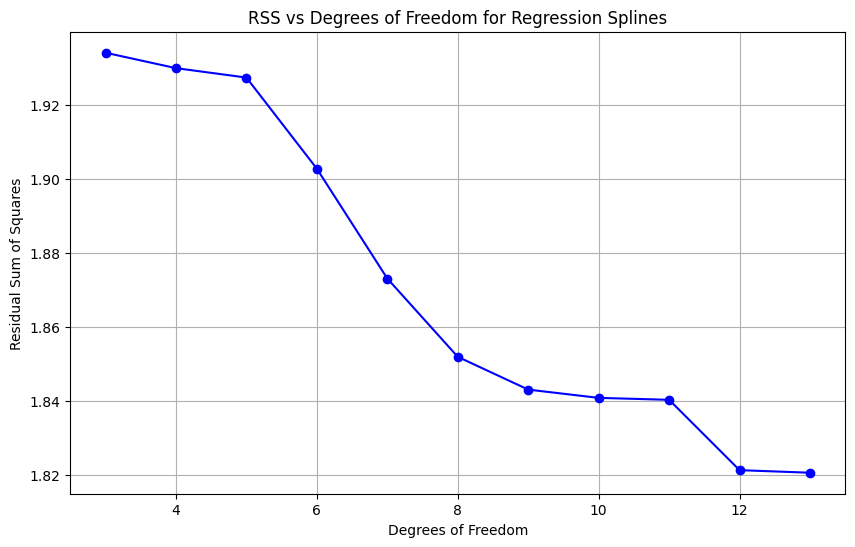


Residual Sum of Squares for each degree of freedom:
df=3: 1.9341
df=4: 1.9299
df=5: 1.9274
df=6: 1.9028
df=7: 1.8731
df=8: 1.8520
df=9: 1.8431
df=10: 1.8409
df=11: 1.8404
df=12: 1.8214
df=13: 1.8207


In [21]:
# Try different degrees of freedom (number of knots)
max_knots = 12
n_knots_range = range(2, max_knots + 1)
rss_splines = []

plt.figure(figsize=(12, 6))
plt.scatter(X, y, alpha=0.3, label='Data', color='gray')

for n_knots in n_knots_range:
    # Create and fit spline transformation
    knots = np.percentile(X.ravel(), np.linspace(0, 100, n_knots + 2)[1:-1])
    spline = SplineTransformer(n_knots=n_knots, degree=3, include_bias=False)
    X_spline = spline.fit_transform(X)
    
    # Fit model
    model = LinearRegression()
    model.fit(X_spline, y)
    
    # Calculate RSS
    y_pred = model.predict(X_spline)
    rss = np.sum((y - y_pred)**2)
    rss_splines.append(rss)
    
    # Generate smooth curve for plotting
    X_new = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    X_new_spline = spline.transform(X_new)
    y_new = model.predict(X_new_spline)
    
    plt.plot(X_new, y_new, label=f'df={n_knots+1}', alpha=0.7)

plt.xlabel('Distance to Employment Centers')
plt.ylabel('NOx Concentration')
plt.title('Regression Splines with Different Degrees of Freedom')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot RSS values
plt.figure(figsize=(10, 6))
plt.plot([n+1 for n in n_knots_range], rss_splines, 'bo-')
plt.xlabel('Degrees of Freedom')
plt.ylabel('Residual Sum of Squares')
plt.title('RSS vs Degrees of Freedom for Regression Splines')
plt.grid(True)
plt.show()

# Print RSS values
print("\nResidual Sum of Squares for each degree of freedom:")
for n_knots, rss in zip(n_knots_range, rss_splines):
    print(f"df={n_knots+1}: {rss:.4f}")

## Cross-validation for Optimal Spline Degrees of Freedom

We'll use k-fold cross-validation to select the optimal degrees of freedom for the regression spline.

Optimal degrees of freedom from cross-validation: 11


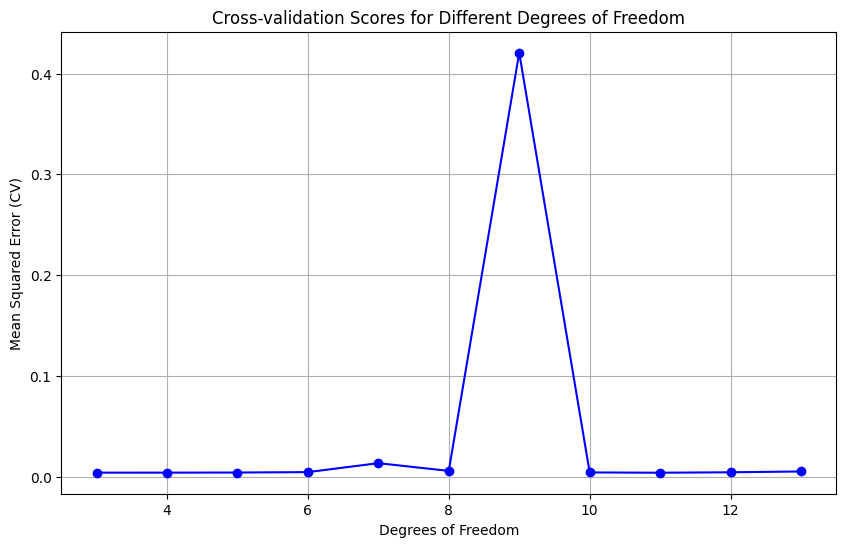

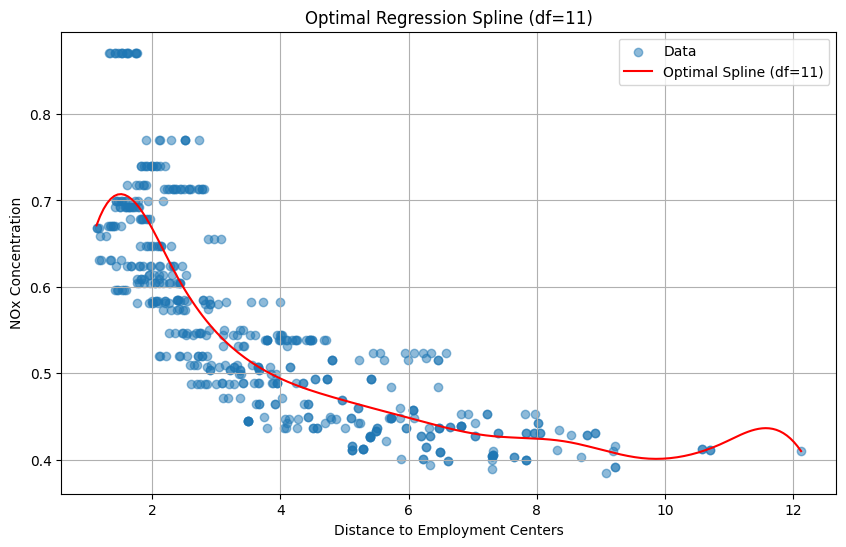


RSS for optimal spline (df=11): 1.8404

Knot locations:
Knot 1: 1.61
Knot 2: 1.90
Knot 3: 2.14
Knot 4: 2.47
Knot 5: 2.87
Knot 6: 3.50
Knot 7: 4.08
Knot 8: 4.83
Knot 9: 5.88
Knot 10: 7.05


In [22]:
# Perform k-fold cross-validation for different numbers of knots
n_folds = 5
max_knots = 12
n_knots_range = range(2, max_knots + 1)
cv_scores_spline = []

for n_knots in n_knots_range:
    # Create spline features
    spline = SplineTransformer(n_knots=n_knots, degree=3, include_bias=False)
    X_spline = spline.fit_transform(X)
    
    # Perform cross-validation
    model = LinearRegression()
    scores = -cross_val_score(model, X_spline, y,
                           cv=KFold(n_splits=n_folds, shuffle=True, random_state=42),
                           scoring='neg_mean_squared_error')
    cv_scores_spline.append(np.mean(scores))

# Find optimal number of knots
optimal_knots = n_knots_range[np.argmin(cv_scores_spline)]
optimal_df = optimal_knots + 1
print(f"Optimal degrees of freedom from cross-validation: {optimal_df}")

# Plot cross-validation scores
plt.figure(figsize=(10, 6))
plt.plot([n+1 for n in n_knots_range], cv_scores_spline, 'bo-')
plt.xlabel('Degrees of Freedom')
plt.ylabel('Mean Squared Error (CV)')
plt.title('Cross-validation Scores for Different Degrees of Freedom')
plt.grid(True)
plt.show()

# Fit spline with optimal degrees of freedom
spline_optimal = SplineTransformer(n_knots=optimal_knots, degree=3, include_bias=False)
X_spline_optimal = spline_optimal.fit_transform(X)
model_optimal = LinearRegression()
model_optimal.fit(X_spline_optimal, y)

# Generate predictions for plotting
X_new = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_new_spline = spline_optimal.transform(X_new)
y_pred = model_optimal.predict(X_new_spline)

# Plot the optimal fit
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Data')
plt.plot(X_new, y_pred, 'r-', label=f'Optimal Spline (df={optimal_df})')
plt.xlabel('Distance to Employment Centers')
plt.ylabel('NOx Concentration')
plt.title(f'Optimal Regression Spline (df={optimal_df})')
plt.legend()
plt.grid(True)
plt.show()

# Print optimal model information
rss_optimal = np.sum((y - model_optimal.predict(X_spline_optimal))**2)
print(f"\nRSS for optimal spline (df={optimal_df}): {rss_optimal:.4f}")
print("\nKnot locations:")
knots = np.percentile(X.ravel(), np.linspace(0, 100, optimal_knots + 2)[1:-1])
for i, knot in enumerate(knots, 1):
    print(f"Knot {i}: {knot:.2f}")